In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path("/Users/harperli/Desktop/Warwick/Final paper/diss_folder")

os.chdir(PROJECT_DIR)

print("Now working in:")
print(os.getcwd())

print("\nKey files:")
for name in [
    "shared_framing_features_dataset.csv",
    "factual_personal_results_for_dissertation.xlsx",
    "preference_articulation_results_for_dissertation.xlsx",
    "self_disclosure_vulnerability_results_for_dissertation.xlsx",
]:
    print(name, Path(name).exists())

Now working in:
/Users/harperli/Desktop/Warwick/Final paper/diss_folder

Key files:
shared_framing_features_dataset.csv True
factual_personal_results_for_dissertation.xlsx True
preference_articulation_results_for_dissertation.xlsx True
self_disclosure_vulnerability_results_for_dissertation.xlsx True


In [2]:
%pip install -q scikit-learn openpyxl matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.inspection import permutation_importance

RANDOM_SEED = 42

OUTDIR = Path("supervised_ml_outputs")
OUTDIR.mkdir(exist_ok=True)

SHARED_PATH = Path("shared_framing_features_dataset.csv")

REDDIT_PATH = Path(
    "/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/reddit_english_only_classified.csv"
)

WILDCHAT_PATH = Path(
    "/Users/harperli/Documents/Codex/2026-07-11/the-attached-notebook-already-contains-our/outputs/wildchat_20k_radvice_classified.csv"
)

FACTUAL_PATH = Path("factual_personal_results_for_dissertation.xlsx")
PREFERENCE_PATH = Path("preference_articulation_results_for_dissertation.xlsx")
DISCLOSURE_PATH = Path("self_disclosure_vulnerability_results_for_dissertation.xlsx")

In [4]:
## Load Shared Dataset And Add Domain
shared = pd.read_csv(SHARED_PATH)
reddit = pd.read_csv(REDDIT_PATH)
wildchat = pd.read_csv(WILDCHAT_PATH)

# Reddit source_id is based on the filtered Reddit advice-case order.
reddit_cases = reddit[
    reddit["personal_practical_advice"].astype(str).str.strip().str.lower() == "yes"
].copy().reset_index(drop=True)

reddit_cases["source_id"] = [f"reddit_{i}" for i in range(len(reddit_cases))]

# WildChat source_id is based on the filtered r/Advice-compatible WildChat order.
wildchat_cases = wildchat[
    wildchat["radvice_compatible"].astype(str).str.strip().str.lower().isin(["yes", "borderline"])
].copy().reset_index(drop=True)

wildchat_cases["source_id"] = [f"wildchat_{i}" for i in range(len(wildchat_cases))]

domain_lookup = pd.concat(
    [
        reddit_cases[["source_id", "domain"]],
        wildchat_cases[["source_id", "domain"]],
    ],
    ignore_index=True
)

df = shared.merge(domain_lookup, on="source_id", how="left")

if df["domain"].isna().any():
    raise ValueError("Some rows are missing domain labels.")

print(df.shape)
print(df["platform"].value_counts())
display(pd.crosstab(df["domain"], df["platform"]))

(1159, 28)
platform
Reddit      976
WildChat    183
Name: count, dtype: int64


platform,Reddit,WildChat
domain,,
career_work,110,54
creative,12,4
daily_life_practical,70,23
education_application,98,15
family,104,7
finance_business,49,28
health_wellbeing,126,21
legal_bureaucratic,68,9
other,1,0


In [5]:
## Add Factual / Preference / Disclosure Features

def attach_coded_sheet(base_df, excel_path, sheet_name, cols_to_add):
    coded = pd.read_excel(excel_path, sheet_name=sheet_name)

    # These coded case files follow the same Reddit-then-WildChat order.
    coded = coded.copy()
    coded["source_id"] = base_df["source_id"].values

    return base_df.merge(
        coded[["source_id"] + cols_to_add],
        on="source_id",
        how="left"
    )

df = attach_coded_sheet(
    df,
    FACTUAL_PATH,
    "Coded Cases",
    ["factual_personal_label", "personal_situated_score"]
)

df = attach_coded_sheet(
    df,
    PREFERENCE_PATH,
    "Coded Cases",
    ["preference_level"]
)

df = attach_coded_sheet(
    df,
    DISCLOSURE_PATH,
    "Coded Cases",
    [
        "self_disclosure_depth",
        "vulnerability_marker_present",
    ]
)

print(df.shape)
display(df.head())

(1159, 33)


,source_id,platform,analysis_text,text_representation,conversation_hash,first_user_text,full_dialogue_text_for_audit,word_count,decision_delegation,narrative_context,...,harsh_truth_request,step_by_step_request,template_request,self_evaluation_request,domain,factual_personal_label,personal_situated_score,preference_level,self_disclosure_depth,vulnerability_marker_present
0,reddit_0,Reddit,How do I stop compulsively lying?\n\nSometimes...,reddit_post,NaN,NaN,NaN,30,1,1,...,0,1,0,0,health_wellbeing,personal_situated,1,2_clear_stated_preference,2_personal_difficulty_or_preference,0
1,reddit_1,Reddit,Why do I imitate others without realizing it?\...,reddit_post,NaN,NaN,NaN,66,0,1,...,0,0,0,0,health_wellbeing,personal_situated,1,1_weak_or_implicit_preference,2_personal_difficulty_or_preference,0
2,reddit_2,Reddit,Feel like I'm not good enough for anyone.\n\nH...,reddit_post,NaN,NaN,NaN,598,1,1,...,0,1,0,0,health_wellbeing,personal_situated,1,2_clear_stated_preference,3_vulnerable_or_intimate_disclosure,1
3,reddit_3,Reddit,"I worked my ass off to overcome poverty, now I...",reddit_post,NaN,NaN,NaN,295,0,1,...,0,0,0,0,finance_business,personal_situated,1,2_clear_stated_preference,2_personal_difficulty_or_preference,0
4,reddit_4,Reddit,I need advice on what to do this weekend. Pret...,reddit_post,NaN,NaN,NaN,63,1,1,...,0,0,0,0,daily_life_practical,personal_situated,1,0_no_stated_preference,1_factual_context,0


In [6]:
## Build ML Feature Table

binary_features = [
    "decision_delegation",
    "narrative_context",
    "emotional_disclosure",
    "social_embeddedness_llm",
    "communication_oriented_request",
    "uncertainty_expression",
    "objective_analysis_request",
    "sympathy_support_request",
    "harsh_truth_request",
    "step_by_step_request",
    "template_request",
    "self_evaluation_request",
    "vulnerability_marker_present",
]

for col in binary_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce")
df["log_word_count"] = np.log1p(df["word_count"])

# Target variable: 1 = WildChat / AI-directed, 0 = Reddit / human-directed.
df["is_wildchat"] = (df["platform"] == "WildChat").astype(int)

categorical_features = [
    "domain",
    "factual_personal_label",
    "preference_level",
    "self_disclosure_depth",
]

numeric_features = binary_features + [
    "log_word_count",
    "personal_situated_score",
]

model_df = df[
    ["source_id", "platform", "is_wildchat"]
    + numeric_features
    + categorical_features
].copy()

for col in categorical_features:
    model_df[col] = model_df[col].fillna("missing").astype(str)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0)

X = model_df[numeric_features + categorical_features]
y = model_df["is_wildchat"]

print("Feature matrix:", X.shape)
print("Target distribution:")
print(y.value_counts())
display(X.head())

Feature matrix: (1159, 19)
Target distribution:
is_wildchat
0    976
1    183
Name: count, dtype: int64


,decision_delegation,narrative_context,emotional_disclosure,social_embeddedness_llm,communication_oriented_request,uncertainty_expression,objective_analysis_request,sympathy_support_request,harsh_truth_request,step_by_step_request,template_request,self_evaluation_request,vulnerability_marker_present,log_word_count,personal_situated_score,domain,factual_personal_label,preference_level,self_disclosure_depth
0,1,1,0,1,0,0,0,0,0,1,0,0,0,3.433987,1,health_wellbeing,personal_situated,2_clear_stated_preference,2_personal_difficulty_or_preference
1,0,1,1,1,0,0,1,0,0,0,0,0,0,4.204693,1,health_wellbeing,personal_situated,1_weak_or_implicit_preference,2_personal_difficulty_or_preference
2,1,1,1,1,0,0,0,0,0,1,0,0,1,6.395262,1,health_wellbeing,personal_situated,2_clear_stated_preference,3_vulnerable_or_intimate_disclosure
3,0,1,1,1,0,0,0,0,0,0,0,0,0,5.690359,1,finance_business,personal_situated,2_clear_stated_preference,2_personal_difficulty_or_preference
4,1,1,1,1,0,0,0,0,0,0,0,0,0,4.158883,1,daily_life_practical,personal_situated,0_no_stated_preference,1_factual_context


In [7]:
## Train/Test Split And Preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", onehot, categorical_features),
    ],
    remainder="drop"
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (869, 19) {0: 732, 1: 137}
Test: (290, 19) {0: 244, 1: 46}


In [8]:
#Define Models

models = {
    "Dummy baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Linear classifier baseline": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Random forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ),

    "Gradient boosting": GradientBoostingClassifier(
        random_state=RANDOM_SEED
    ),
}

In [9]:
##Cross-Validation Model Comparison

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "f1_wildchat": "f1",
    "precision_wildchat": "precision",
    "recall_wildchat": "recall",
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_rows = []

for model_name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model),
        ]
    )

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    row = {"model": model_name}

    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_sd"] = values.std()

    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(
    "balanced_accuracy_mean",
    ascending=False
)

display(cv_results)

cv_results.to_csv(
    OUTDIR / "cv_model_comparison.csv",
    index=False
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_

,model,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,roc_auc_mean,roc_auc_sd,f1_wildchat_mean,f1_wildchat_sd,precision_wildchat_mean,precision_wildchat_sd,recall_wildchat_mean,recall_wildchat_sd
1,Linear classifier baseline,0.892957,0.019922,0.882727,0.033723,0.943229,0.020928,0.719598,0.046920,0.618295,0.057121,0.867989,0.072741
2,Random forest,0.917142,0.019457,0.878975,0.037659,0.951704,0.022447,0.758186,0.053682,0.706973,0.063446,0.823545,0.076973
3,Gradient boosting,0.940144,0.013502,0.857054,0.035820,0.948397,0.027466,0.793338,0.051567,0.865814,0.059243,0.735979,0.071068
0,Dummy baseline,0.842349,0.002689,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
## Fit Best Model And Evaluate On Test Set

best_model_name = cv_results.iloc[0]["model"]
best_model = models[best_model_name]

best_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", best_model),
    ]
)

best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)

if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    y_score = best_pipe.predict_proba(X_test)[:, 1]
else:
    y_score = best_pipe.decision_function(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="binary",
    pos_label=1
)

test_results = {
    "best_model": best_model_name,
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_score),
    "wildchat_precision": precision,
    "wildchat_recall": recall,
    "wildchat_f1": f1,
}

test_results_df = pd.DataFrame([test_results])
display(test_results_df)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Reddit", "WildChat"]
))

test_results_df.to_csv(
    OUTDIR / "test_set_results.csv",
    index=False
)

,best_model,accuracy,balanced_accuracy,roc_auc,wildchat_precision,wildchat_recall,wildchat_f1
0,Linear classifier baseline,0.886207,0.879455,0.973004,0.597015,0.869565,0.707965


              precision    recall  f1-score   support

      Reddit       0.97      0.89      0.93       244
    WildChat       0.60      0.87      0.71        46

    accuracy                           0.89       290
   macro avg       0.79      0.88      0.82       290
weighted avg       0.91      0.89      0.89       290



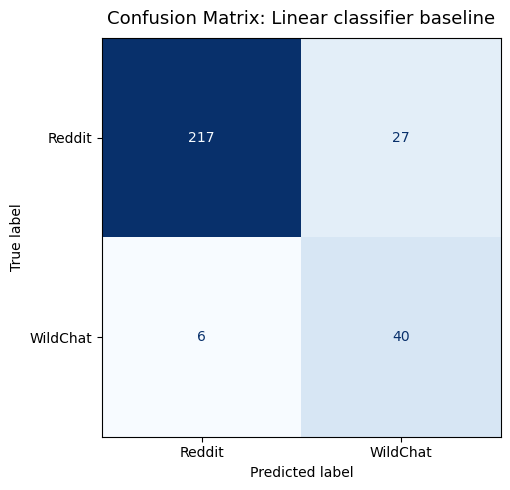

In [11]:
## Confusion Matrix Plot

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Reddit", "WildChat"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

ax.set_title(
    f"Confusion Matrix: {best_model_name}",
    fontsize=13,
    pad=10
)

plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
## Permutation Feature Importance

perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_sd": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

importance_df.to_csv(
    OUTDIR / "permutation_feature_importance.csv",
    index=False
)

,feature,importance_mean,importance_sd
13,log_word_count,0.094188,0.024234
7,sympathy_support_request,0.007597,0.007925
15,domain,0.007044,0.017325
10,template_request,0.006932,0.009021
1,narrative_context,0.005871,0.007015
8,harsh_truth_request,0.000226,0.002041
9,step_by_step_request,-0.000205,0.001434
11,self_evaluation_request,-0.000342,0.000764
14,personal_situated_score,-0.001161,0.001261
17,preference_level,-0.002254,0.003190


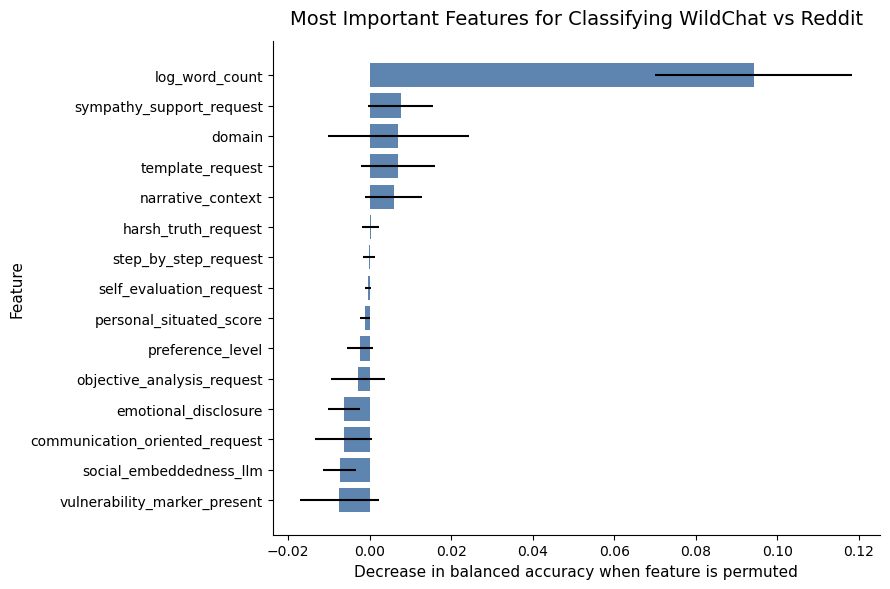

In [13]:
## Feature Importance Plot

top_n = 15

plot_df = importance_df.head(top_n).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, 6))

ax = plt.gca()

ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_sd"],
    color="#4C78A8",
    alpha=0.9
)

ax.set_title(
    "Most Important Features for Classifying WildChat vs Reddit",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Decrease in balanced accuracy when feature is permuted",
    fontsize=11
)

ax.set_ylabel("Feature", fontsize=11)

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
model_df.to_csv(
    OUTDIR / "supervised_ml_modeling_dataset.csv",
    index=False
)

print("Saved outputs to:", OUTDIR.resolve())

Saved outputs to: /Users/harperli/Desktop/Warwick/Final paper/diss_folder/supervised_ml_outputs


In [15]:
## try to find results

import os
from pathlib import Path

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
for p in Path(".").glob("*"):
    print(p)

Current working directory:
/Users/harperli/Desktop/Warwick/Final paper/diss_folder

Files here:
users' prompting.pdf
examples_by_domain.xlsx
who is feeling whom.pdf
factual_personal_results_for_dissertation.xlsx
self_disclosure_vulnerability_results_for_dissertation.xlsx
all_examples_by_domain.xlsx
rq2_framing_profile_analysis.ipynb
literature_notes.xlsx
__pycache__
Proceedings of the Association for Information Science and Technology - 2024 - Ju - Empowering Users with ChatGPT and.pdf
beyond_rational_choice.pdf
limeade.pdf
framing_results.xlsx
preference_articulation_results_for_dissertation.xlsx
how_AI_and_human.pdf
shared_framing_features_dataset.csv
do_human_trust_advice_more.pdf
diss3_original_plus_framing.ipynb
organizational.pdf
rq2_framing_profile_analysis.py
rq2_profile_outputs
dissertation_general_results.xlsx
Theories_of_Computer_Mediated_Communicat.pdf
supervised_ml_outputs
intimate_exchange.pdf
receiving_other_ppl.pdf
liao-et-al-2024-on-the-motivations-to-seek-information-

In [16]:
##Define Feature Sets For Ablation Models

# Ablation analysis: compare full model with reduced feature sets

from sklearn.base import clone

# Full model: everything used before
full_numeric_features = numeric_features.copy()
full_categorical_features = categorical_features.copy()

# No-length model: remove log_word_count
no_length_numeric_features = [
    f for f in numeric_features
    if f != "log_word_count"
]
no_length_categorical_features = categorical_features.copy()

# Framing-only model:
# remove log_word_count and domain; keep coded framing/content-analysis features
framing_only_numeric_features = [
    f for f in numeric_features
    if f != "log_word_count"
]

framing_only_categorical_features = [
    f for f in categorical_features
    if f != "domain"
]

feature_sets = {
    "Full model": {
        "numeric": full_numeric_features,
        "categorical": full_categorical_features,
    },
    "No-length model": {
        "numeric": no_length_numeric_features,
        "categorical": no_length_categorical_features,
    },
    "Framing-only model": {
        "numeric": framing_only_numeric_features,
        "categorical": framing_only_categorical_features,
    },
}

for name, spec in feature_sets.items():
    print("\n", name)
    print("Numeric:", spec["numeric"])
    print("Categorical:", spec["categorical"])


 Full model
Numeric: ['decision_delegation', 'narrative_context', 'emotional_disclosure', 'social_embeddedness_llm', 'communication_oriented_request', 'uncertainty_expression', 'objective_analysis_request', 'sympathy_support_request', 'harsh_truth_request', 'step_by_step_request', 'template_request', 'self_evaluation_request', 'vulnerability_marker_present', 'log_word_count', 'personal_situated_score']
Categorical: ['domain', 'factual_personal_label', 'preference_level', 'self_disclosure_depth']

 No-length model
Numeric: ['decision_delegation', 'narrative_context', 'emotional_disclosure', 'social_embeddedness_llm', 'communication_oriented_request', 'uncertainty_expression', 'objective_analysis_request', 'sympathy_support_request', 'harsh_truth_request', 'step_by_step_request', 'template_request', 'self_evaluation_request', 'vulnerability_marker_present', 'personal_situated_score']
Categorical: ['domain', 'factual_personal_label', 'preference_level', 'self_disclosure_depth']

 Framing

In [17]:
## Helper Function For Ablation Evaluation

def make_preprocess(numeric_cols, categorical_cols):
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", onehot, categorical_cols),
        ],
        remainder="drop"
    )

def evaluate_feature_set(feature_set_name, numeric_cols, categorical_cols, model_name, model):
    selected_features = numeric_cols + categorical_cols

    X_selected = model_df[selected_features]
    y_selected = model_df["is_wildchat"]

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_selected,
        y_selected,
        test_size=0.25,
        random_state=RANDOM_SEED,
        stratify=y_selected
    )

    preprocess_s = make_preprocess(numeric_cols, categorical_cols)

    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess_s),
            ("model", clone(model)),
        ]
    )

    cv_scores = cross_validate(
        pipe,
        X_train_s,
        y_train_s,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    pipe.fit(X_train_s, y_train_s)

    y_pred_s = pipe.predict(X_test_s)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_score_s = pipe.predict_proba(X_test_s)[:, 1]
    else:
        y_score_s = pipe.decision_function(X_test_s)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_s,
        y_pred_s,
        average="binary",
        pos_label=1
    )

    result = {
        "feature_set": feature_set_name,
        "model": model_name,
        "n_features_raw": len(selected_features),
        "cv_balanced_accuracy_mean": cv_scores["test_balanced_accuracy"].mean(),
        "cv_balanced_accuracy_sd": cv_scores["test_balanced_accuracy"].std(),
        "cv_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
        "cv_roc_auc_sd": cv_scores["test_roc_auc"].std(),
        "cv_f1_wildchat_mean": cv_scores["test_f1_wildchat"].mean(),
        "cv_f1_wildchat_sd": cv_scores["test_f1_wildchat"].std(),
        "test_accuracy": accuracy_score(y_test_s, y_pred_s),
        "test_balanced_accuracy": balanced_accuracy_score(y_test_s, y_pred_s),
        "test_roc_auc": roc_auc_score(y_test_s, y_score_s),
        "test_wildchat_precision": precision,
        "test_wildchat_recall": recall,
        "test_wildchat_f1": f1,
    }

    return result, pipe, X_test_s, y_test_s, y_pred_s, y_score_s

In [18]:
## Run Ablation Models

# Use the best-performing model family from the previous comparison.
# In your current run this was the Linear classifier baseline.
ablation_model_name = best_model_name
ablation_model = models[ablation_model_name]

ablation_rows = []
ablation_artifacts = {}

for feature_set_name, spec in feature_sets.items():
    result, pipe, X_test_s, y_test_s, y_pred_s, y_score_s = evaluate_feature_set(
        feature_set_name=feature_set_name,
        numeric_cols=spec["numeric"],
        categorical_cols=spec["categorical"],
        model_name=ablation_model_name,
        model=ablation_model
    )

    ablation_rows.append(result)

    ablation_artifacts[feature_set_name] = {
        "pipe": pipe,
        "X_test": X_test_s,
        "y_test": y_test_s,
        "y_pred": y_pred_s,
        "y_score": y_score_s,
        "numeric": spec["numeric"],
        "categorical": spec["categorical"],
    }

ablation_results = pd.DataFrame(ablation_rows)

display(ablation_results)

ablation_results.to_csv(
    OUTDIR / "ablation_model_comparison.csv",
    index=False
)

,feature_set,model,n_features_raw,cv_balanced_accuracy_mean,cv_balanced_accuracy_sd,cv_roc_auc_mean,cv_roc_auc_sd,cv_f1_wildchat_mean,cv_f1_wildchat_sd,test_accuracy,test_balanced_accuracy,test_roc_auc,test_wildchat_precision,test_wildchat_recall,test_wildchat_f1
0,Full model,Linear classifier baseline,19,0.882727,0.033723,0.943229,0.020928,0.719598,0.046920,0.886207,0.879455,0.973004,0.597015,0.869565,0.707965
1,No-length model,Linear classifier baseline,18,0.832425,0.036042,0.922622,0.012233,0.644856,0.050095,0.855172,0.852192,0.952824,0.527027,0.847826,0.650000
2,Framing-only model,Linear classifier baseline,17,0.833403,0.024670,0.923226,0.016508,0.643699,0.051004,0.872414,0.844797,0.945251,0.569231,0.804348,0.666667


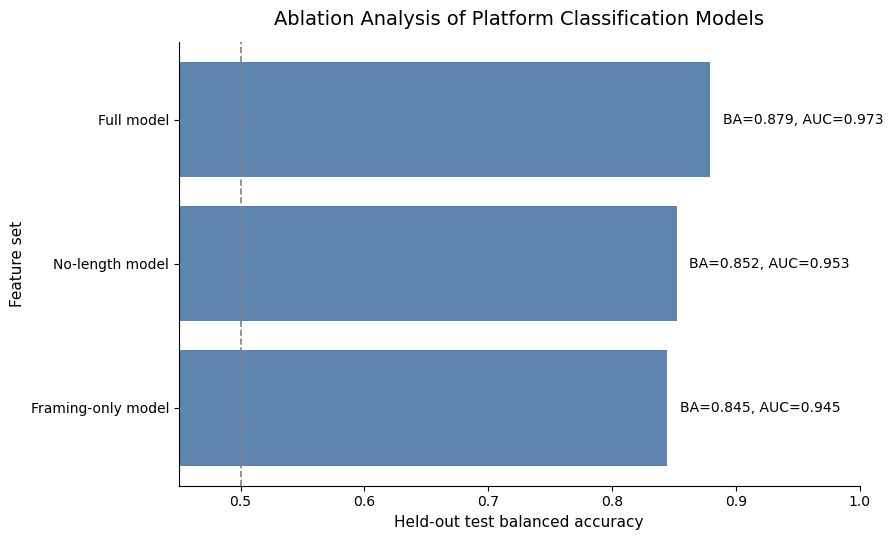

In [19]:
## Ablation Results Plot

# Figure: Ablation comparison

plot_df = ablation_results.copy()

plot_df = plot_df.sort_values("test_balanced_accuracy", ascending=True)

plt.figure(figsize=(9, 5.5))

ax = plt.gca()

ax.barh(
    plot_df["feature_set"],
    plot_df["test_balanced_accuracy"],
    color="#4C78A8",
    alpha=0.9,
    label="Balanced accuracy"
)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["test_balanced_accuracy"] + 0.01,
        i,
        f'BA={row["test_balanced_accuracy"]:.3f}, AUC={row["test_roc_auc"]:.3f}',
        va="center",
        fontsize=10
    )

ax.axvline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label="Chance level"
)

ax.set_xlim(0.45, 1.0)

ax.set_title(
    "Ablation Analysis of Platform Classification Models",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Held-out test balanced accuracy",
    fontsize=11
)

ax.set_ylabel("Feature set", fontsize=11)

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_ablation_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

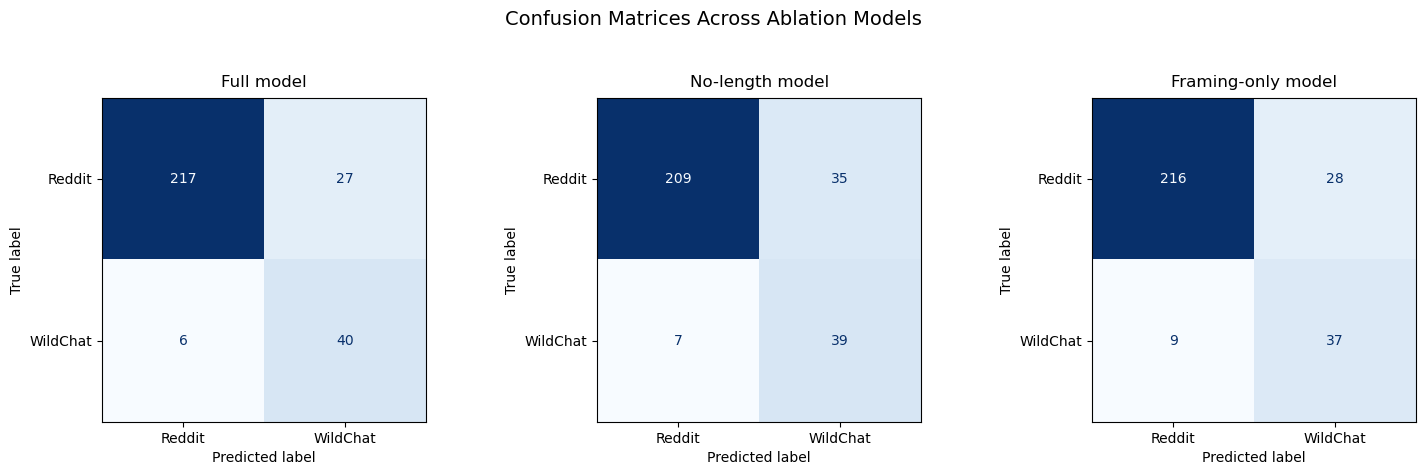

In [20]:
## Confusion Matrices For Ablation Models

# Confusion matrices for each ablation model

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(ablation_artifacts),
    figsize=(15, 4.5)
)

if len(ablation_artifacts) == 1:
    axes = [axes]

for ax, (feature_set_name, artifact) in zip(axes, ablation_artifacts.items()):
    cm = confusion_matrix(
        artifact["y_test"],
        artifact["y_pred"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Reddit", "WildChat"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(feature_set_name, fontsize=12, pad=8)

fig.suptitle(
    "Confusion Matrices Across Ablation Models",
    fontsize=14,
    y=1.04
)

plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_ablation_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Permutation importance for the no-length model

artifact = ablation_artifacts["No-length model"]
pipe = artifact["pipe"]
X_test_no_length = artifact["X_test"]
y_test_no_length = artifact["y_test"]

perm_no_length = permutation_importance(
    pipe,
    X_test_no_length,
    y_test_no_length,
    scoring="balanced_accuracy",
    n_repeats=30,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

importance_no_length = pd.DataFrame({
    "feature": X_test_no_length.columns,
    "importance_mean": perm_no_length.importances_mean,
    "importance_sd": perm_no_length.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_no_length.head(20))

importance_no_length.to_csv(
    OUTDIR / "permutation_feature_importance_no_length_model.csv",
    index=False
)

,feature,importance_mean,importance_sd
1,narrative_context,0.047787,0.009383
14,domain,0.008722,0.015028
13,personal_situated_score,0.005907,0.005538
9,step_by_step_request,0.004891,0.008676
7,sympathy_support_request,0.003005,0.007649
17,self_disclosure_depth,0.001616,0.013464
2,emotional_disclosure,0.000769,0.010061
8,harsh_truth_request,0.000383,0.002903
4,communication_oriented_request,-0.000104,0.005486
16,preference_level,-0.000309,0.009138


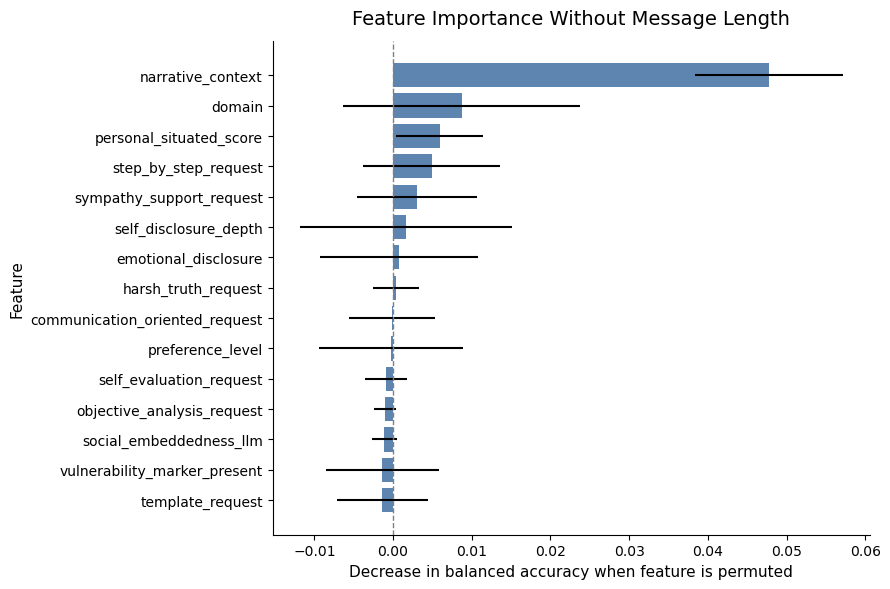

In [22]:
## Plot No-Length Feature Importance

top_n = 15

plot_df = importance_no_length.head(top_n).sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(9, 6))

ax = plt.gca()

ax.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_sd"],
    color="#4C78A8",
    alpha=0.9
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Feature Importance Without Message Length",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Decrease in balanced accuracy when feature is permuted",
    fontsize=11
)

ax.set_ylabel("Feature", fontsize=11)

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_permutation_feature_importance_no_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
## Create Final Summary Table

# Final dissertation-ready model summary table

final_model_summary = ablation_results[
    [
        "feature_set",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_roc_auc",
        "test_wildchat_precision",
        "test_wildchat_recall",
        "test_wildchat_f1",
    ]
].copy()

final_model_summary = final_model_summary.rename(columns={
    "feature_set": "Feature set",
    "test_accuracy": "Accuracy",
    "test_balanced_accuracy": "Balanced accuracy",
    "test_roc_auc": "ROC-AUC",
    "test_wildchat_precision": "WildChat precision",
    "test_wildchat_recall": "WildChat recall",
    "test_wildchat_f1": "WildChat F1",
})

for col in [
    "Accuracy",
    "Balanced accuracy",
    "ROC-AUC",
    "WildChat precision",
    "WildChat recall",
    "WildChat F1",
]:
    final_model_summary[col] = final_model_summary[col].round(3)

display(final_model_summary)

final_model_summary.to_csv(
    OUTDIR / "final_dissertation_model_summary.csv",
    index=False
)

,Feature set,Accuracy,Balanced accuracy,ROC-AUC,WildChat precision,WildChat recall,WildChat F1
0,Full model,0.886,0.879,0.973,0.597,0.870,0.708
1,No-length model,0.855,0.852,0.953,0.527,0.848,0.650
2,Framing-only model,0.872,0.845,0.945,0.569,0.804,0.667


In [24]:
# Clean Feature Names For Importance Plot

# Cleaner feature names for dissertation figures

pretty_feature_names = {
    "log_word_count": "Message length (log word count)",
    "decision_delegation": "Decision delegation",
    "narrative_context": "Narrative context",
    "emotional_disclosure": "Emotional disclosure",
    "social_embeddedness_llm": "Social embeddedness",
    "communication_oriented_request": "Communication-oriented request",
    "uncertainty_expression": "Uncertainty expression",
    "objective_analysis_request": "Objective analysis request",
    "sympathy_support_request": "Sympathy/support request",
    "harsh_truth_request": "Harsh truth request",
    "step_by_step_request": "Step-by-step request",
    "template_request": "Template/message request",
    "self_evaluation_request": "Self-evaluation request",
    "vulnerability_marker_present": "Vulnerability marker",
    "personal_situated_score": "Personal/situated score",
    "domain": "Advice domain",
    "factual_personal_label": "Factual/personal label",
    "preference_level": "Preference articulation",
    "self_disclosure_depth": "Self-disclosure depth",
}

importance_no_length_clean = importance_no_length.copy()
importance_no_length_clean["feature_pretty"] = importance_no_length_clean["feature"].map(
    pretty_feature_names
).fillna(importance_no_length_clean["feature"])

importance_no_length_clean = importance_no_length_clean.sort_values(
    "importance_mean",
    ascending=False
)

display(importance_no_length_clean.head(15))

importance_no_length_clean.to_csv(
    OUTDIR / "permutation_feature_importance_no_length_model_clean.csv",
    index=False
)

,feature,importance_mean,importance_sd,feature_pretty
1,narrative_context,0.047787,0.009383,Narrative context
14,domain,0.008722,0.015028,Advice domain
13,personal_situated_score,0.005907,0.005538,Personal/situated score
9,step_by_step_request,0.004891,0.008676,Step-by-step request
7,sympathy_support_request,0.003005,0.007649,Sympathy/support request
17,self_disclosure_depth,0.001616,0.013464,Self-disclosure depth
2,emotional_disclosure,0.000769,0.010061,Emotional disclosure
8,harsh_truth_request,0.000383,0.002903,Harsh truth request
4,communication_oriented_request,-0.000104,0.005486,Communication-oriented request
16,preference_level,-0.000309,0.009138,Preference articulation


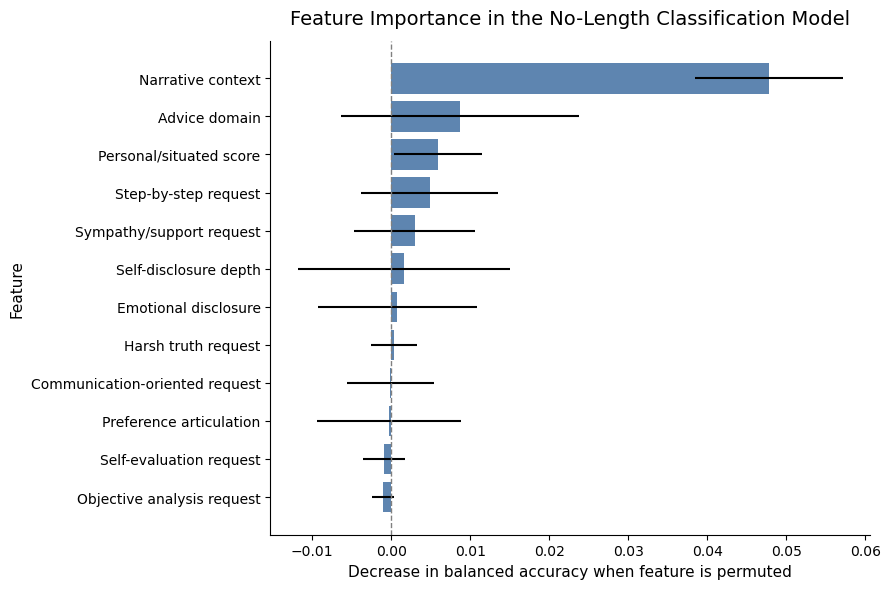

In [25]:
# Cleaner No-Length Feature Importance Plot

# Final Figure: feature importance without message length

top_n = 12

plot_df = importance_no_length_clean.head(top_n).sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(9, 6))

ax = plt.gca()

ax.barh(
    plot_df["feature_pretty"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_sd"],
    color="#4C78A8",
    alpha=0.9
)

ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Feature Importance in the No-Length Classification Model",
    fontsize=14,
    pad=12
)

ax.set_xlabel(
    "Decrease in balanced accuracy when feature is permuted",
    fontsize=11
)

ax.set_ylabel("Feature", fontsize=11)

sns.despine(left=False, bottom=False)
plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_feature_importance_no_length_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

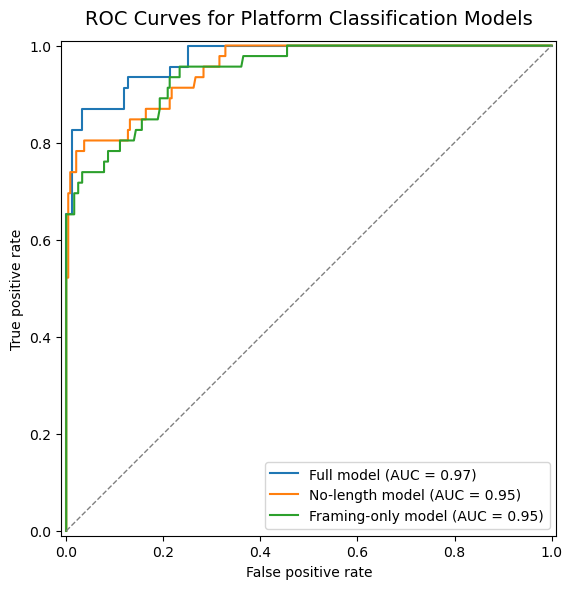

In [26]:
# Figure: ROC curves for final ablation models

from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 6))

ax = plt.gca()

for feature_set_name, artifact in ablation_artifacts.items():
    RocCurveDisplay.from_predictions(
        artifact["y_test"],
        artifact["y_score"],
        name=feature_set_name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1,
    label="Chance"
)

ax.set_title(
    "ROC Curves for Platform Classification Models",
    fontsize=14,
    pad=12
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")

plt.tight_layout()

plt.savefig(
    OUTDIR / "figure_roc_curves_ablation_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Feature set,Accuracy,Balanced accuracy,ROC-AUC,WildChat precision,WildChat recall,WildChat F1
0,Full model,0.886,0.879,0.973,0.597,0.870,0.708
1,No-length model,0.855,0.852,0.953,0.527,0.848,0.650
2,Framing-only model,0.872,0.845,0.945,0.569,0.804,0.667


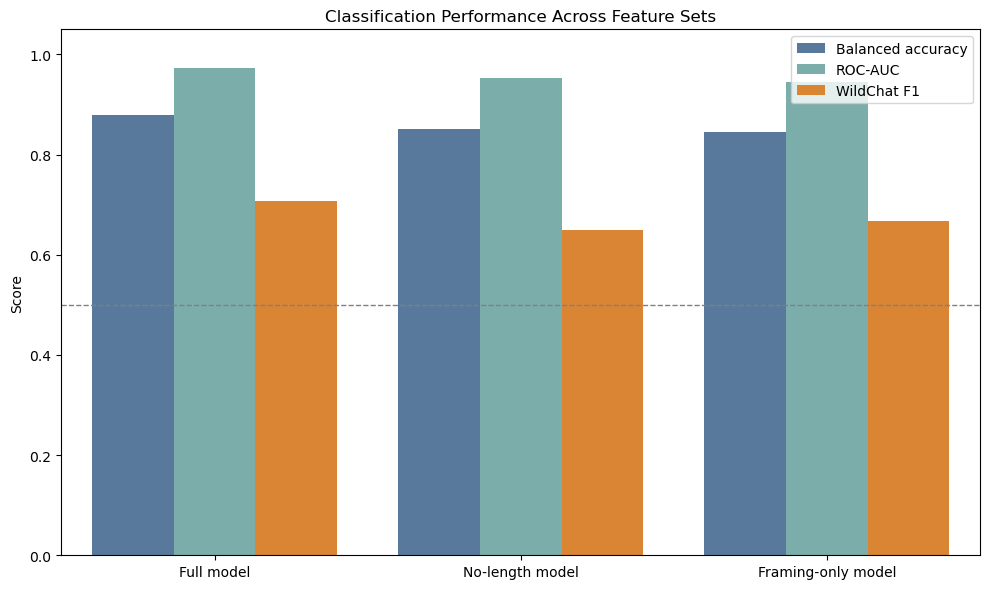

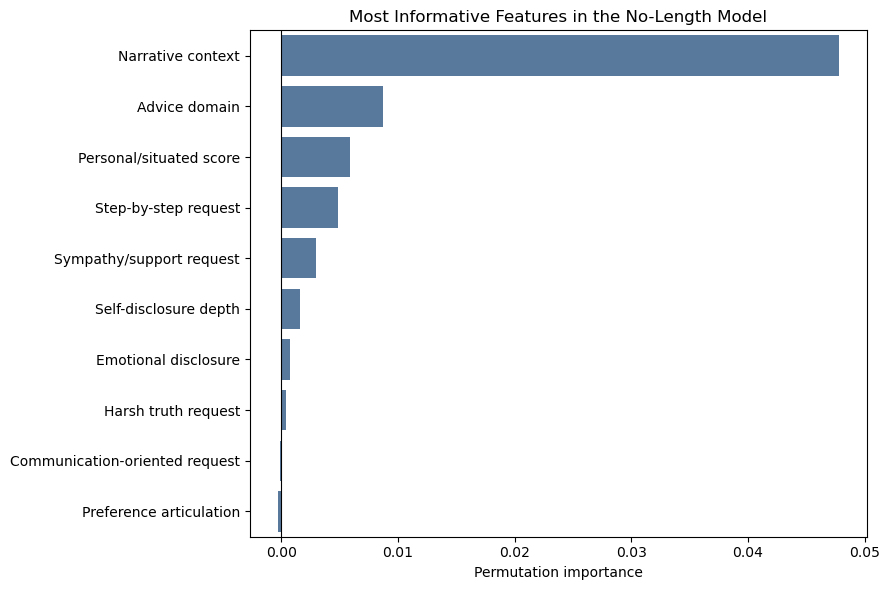


Final supervised ML results summary

The full supervised classification model achieved:
- Accuracy: 0.886
- Balanced accuracy: 0.879
- ROC-AUC: 0.973
- WildChat F1: 0.708

After removing message length, the model still achieved:
- Balanced accuracy: 0.852
- ROC-AUC: 0.953
- WildChat F1: 0.65

Using framing features only, after removing both message length and advice domain, the model achieved:
- Balanced accuracy: 0.845
- ROC-AUC: 0.945
- WildChat F1: 0.667

Interpretation:
The model performed well above the dummy baseline and above chance across all feature sets.
The framing-only model remained strongly predictive, suggesting that AI-directed advice requests
have a distinguishable framing profile that is not reducible to message length or advice domain.

The no-length feature importance analysis identified narrative context as the strongest individual
predictor, consistent with the descriptive finding that Reddit advice requests are more narrative,
whereas WildChat requests tend to b

In [27]:
# ==============================
# Final dissertation-ready outputs
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil

# Set paths
PROJECT_DIR = Path("/Users/harperli/Desktop/Warwick/Final paper/diss_folder")
OUTPUT_DIR = PROJECT_DIR / "supervised_ml_outputs"
FINAL_DIR = OUTPUT_DIR / "final_dissertation_outputs"
FINAL_DIR.mkdir(exist_ok=True)

# Load key result files
summary = pd.read_csv(OUTPUT_DIR / "final_dissertation_model_summary.csv")
ablation = pd.read_csv(OUTPUT_DIR / "ablation_model_comparison.csv")
importance = pd.read_csv(OUTPUT_DIR / "permutation_feature_importance_no_length_model_clean.csv")

# ------------------------------
# 1. Clean final performance table
# ------------------------------

final_table = summary.copy()

metric_cols = [
    "Accuracy",
    "Balanced accuracy",
    "ROC-AUC",
    "WildChat precision",
    "WildChat recall",
    "WildChat F1"
]

for col in metric_cols:
    final_table[col] = final_table[col].round(3)

final_table.to_csv(FINAL_DIR / "table_final_model_performance.csv", index=False)

display(final_table)

# ------------------------------
# 2. Dissertation-ready ablation figure
# ------------------------------

plot_data = final_table.melt(
    id_vars="Feature set",
    value_vars=["Balanced accuracy", "ROC-AUC", "WildChat F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="Feature set",
    y="Score",
    hue="Metric",
    palette=["#4C78A8", "#72B7B2", "#F58518"]
)

plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.ylim(0, 1.05)
plt.xlabel("")
plt.ylabel("Score")
plt.title("Classification Performance Across Feature Sets")
plt.legend(title="")
plt.tight_layout()

plt.savefig(FINAL_DIR / "figure_final_ablation_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 3. Dissertation-ready feature importance figure
# ------------------------------

top_importance = importance.sort_values("importance_mean", ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_importance,
    x="importance_mean",
    y="feature_pretty",
    color="#4C78A8"
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Permutation importance")
plt.ylabel("")
plt.title("Most Informative Features in the No-Length Model")
plt.tight_layout()

plt.savefig(FINAL_DIR / "figure_final_feature_importance_no_length.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 4. Copy already-generated key figures
# ------------------------------

figures_to_copy = [
    "figure_roc_curves_ablation_models.png",
    "figure_ablation_confusion_matrices.png",
    "figure_confusion_matrix.png"
]

for fig in figures_to_copy:
    source = OUTPUT_DIR / fig
    target = FINAL_DIR / fig
    if source.exists():
        shutil.copy(source, target)

# ------------------------------
# 5. Generate plain-language results summary
# ------------------------------

full = final_table[final_table["Feature set"] == "Full model"].iloc[0]
no_length = final_table[final_table["Feature set"] == "No-length model"].iloc[0]
framing_only = final_table[final_table["Feature set"] == "Framing-only model"].iloc[0]

results_text = f"""
Final supervised ML results summary

The full supervised classification model achieved:
- Accuracy: {full['Accuracy']}
- Balanced accuracy: {full['Balanced accuracy']}
- ROC-AUC: {full['ROC-AUC']}
- WildChat F1: {full['WildChat F1']}

After removing message length, the model still achieved:
- Balanced accuracy: {no_length['Balanced accuracy']}
- ROC-AUC: {no_length['ROC-AUC']}
- WildChat F1: {no_length['WildChat F1']}

Using framing features only, after removing both message length and advice domain, the model achieved:
- Balanced accuracy: {framing_only['Balanced accuracy']}
- ROC-AUC: {framing_only['ROC-AUC']}
- WildChat F1: {framing_only['WildChat F1']}

Interpretation:
The model performed well above the dummy baseline and above chance across all feature sets.
The framing-only model remained strongly predictive, suggesting that AI-directed advice requests
have a distinguishable framing profile that is not reducible to message length or advice domain.

The no-length feature importance analysis identified narrative context as the strongest individual
predictor, consistent with the descriptive finding that Reddit advice requests are more narrative,
whereas WildChat requests tend to be more concise and task-oriented.
"""

print(results_text)

with open(FINAL_DIR / "final_results_summary.txt", "w") as f:
    f.write(results_text)

print(f"\nFinal dissertation-ready outputs saved to:\n{FINAL_DIR}")

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.inspection import permutation_importance

PROJECT_DIR = Path("/Users/harperli/Desktop/Warwick/Final paper")
DATA_PATH = PROJECT_DIR / "data results" / "source_coding_files" / "supervised_ml_modeling_dataset.csv"

OUTPUT_DIR = PROJECT_DIR / "data results" / "narrative_context_ml_analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df["platform"].value_counts())
print(pd.crosstab(df["domain"], df["platform"]))

(1159, 22)
platform
Reddit      976
WildChat    183
Name: count, dtype: int64
platform               Reddit  WildChat
domain                                 
career_work               110        54
creative                   12         4
daily_life_practical       70        23
education_application      98        15
family                    104         7
finance_business           49        28
health_wellbeing          126        21
legal_bureaucratic         68         9
other                       1         0
relationship_social       331        21
technical_digital           7         1


In [2]:
domain_counts = pd.crosstab(df["domain"], df["platform"])

eligible_domains = domain_counts[
    (domain_counts.get("Reddit", 0) >= 20) &
    (domain_counts.get("WildChat", 0) >= 15)
].index.tolist()

df["domain_group"] = np.where(
    df["domain"].isin(eligible_domains),
    df["domain"],
    "other_sparse"
)

print(pd.crosstab(df["domain_group"], df["platform"]))

platform               Reddit  WildChat
domain_group                           
career_work               110        54
daily_life_practical       70        23
education_application      98        15
finance_business           49        28
health_wellbeing          126        21
other_sparse              192        21
relationship_social       331        21


In [3]:
def build_classifier(numeric_features, categorical_features):
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", encoder, categorical_features)
        ]
    )

    model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])


def evaluate_model(model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]

    out = {
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "roc_auc": roc_auc_score(y, prob) if y.nunique() == 2 else np.nan,
        "wildchat_precision": precision_score(y, pred, zero_division=0),
        "wildchat_recall": recall_score(y, pred, zero_division=0),
        "wildchat_f1": f1_score(y, pred, zero_division=0)
    }

    return out

In [4]:
target = "is_wildchat"

base_exclude = [
    "source_id",
    "platform",
    "is_wildchat",
    "log_word_count",
    "domain"
]

features_with_narrative = [c for c in df.columns if c not in base_exclude]
features_without_narrative = [
    c for c in features_with_narrative
    if c != "narrative_context"
]

print("Features with narrative:", features_with_narrative)
print("\nFeatures without narrative:", features_without_narrative)

Features with narrative: ['decision_delegation', 'narrative_context', 'emotional_disclosure', 'social_embeddedness_llm', 'communication_oriented_request', 'uncertainty_expression', 'objective_analysis_request', 'sympathy_support_request', 'harsh_truth_request', 'step_by_step_request', 'template_request', 'self_evaluation_request', 'vulnerability_marker_present', 'personal_situated_score', 'factual_personal_label', 'preference_level', 'self_disclosure_depth', 'domain_group']

Features without narrative: ['decision_delegation', 'emotional_disclosure', 'social_embeddedness_llm', 'communication_oriented_request', 'uncertainty_expression', 'objective_analysis_request', 'sympathy_support_request', 'harsh_truth_request', 'step_by_step_request', 'template_request', 'self_evaluation_request', 'vulnerability_marker_present', 'personal_situated_score', 'factual_personal_label', 'preference_level', 'self_disclosure_depth', 'domain_group']


In [5]:
X_all = df[features_with_narrative].copy()
y = df[target].copy()

X_train_all, X_test_all, y_train, y_test, df_train, df_test = train_test_split(
    X_all,
    y,
    df,
    test_size=0.25,
    stratify=y,
    random_state=42
)

X_train_no_narr = X_train_all[features_without_narrative].copy()
X_test_no_narr = X_test_all[features_without_narrative].copy()

In [6]:
def split_feature_types(X):
    categorical = [
        c for c in X.columns
        if X[c].dtype == "object" or c in [
            "domain_group",
            "factual_personal_label",
            "preference_level",
            "self_disclosure_depth"
        ]
    ]
    numeric = [c for c in X.columns if c not in categorical]
    return numeric, categorical


num_with, cat_with = split_feature_types(X_train_all)
num_without, cat_without = split_feature_types(X_train_no_narr)

model_with_narrative = build_classifier(num_with, cat_with)
model_without_narrative = build_classifier(num_without, cat_without)

model_with_narrative.fit(X_train_all, y_train)
model_without_narrative.fit(X_train_no_narr, y_train)

overall_with = evaluate_model(model_with_narrative, X_test_all, y_test)
overall_without = evaluate_model(model_without_narrative, X_test_no_narr, y_test)

overall_comparison = pd.DataFrame([
    {"model": "No-length model with narrative_context", **overall_with},
    {"model": "No-length model without narrative_context", **overall_without}
])

for metric in ["accuracy", "balanced_accuracy", "roc_auc", "wildchat_precision", "wildchat_recall", "wildchat_f1"]:
    overall_comparison[f"{metric}_drop_without_narrative"] = (
        overall_comparison.loc[0, metric] - overall_comparison[metric]
    )

overall_comparison.to_csv(OUTPUT_DIR / "overall_narrative_ablation.csv", index=False)
display(overall_comparison)

,model,accuracy,balanced_accuracy,roc_auc,wildchat_precision,wildchat_recall,wildchat_f1,accuracy_drop_without_narrative,balanced_accuracy_drop_without_narrative,roc_auc_drop_without_narrative,wildchat_precision_drop_without_narrative,wildchat_recall_drop_without_narrative,wildchat_f1_drop_without_narrative
0,No-length model with narrative_context,0.844828,0.837224,0.953181,0.506667,0.826087,0.628099,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,No-length model without narrative_context,0.855172,0.843371,0.945608,0.527778,0.826087,0.644068,-0.010345,-0.006148,0.007573,-0.021111,0.0,-0.015969


In [7]:
narrative_prev = (
    df.groupby(["domain_group", "platform"])["narrative_context"]
    .agg(["mean", "sum", "count"])
    .reset_index()
)

narrative_prev["percent"] = narrative_prev["mean"] * 100

narrative_wide = narrative_prev.pivot(
    index="domain_group",
    columns="platform",
    values="percent"
).reset_index()

narrative_wide["gap_reddit_minus_wildchat"] = (
    narrative_wide.get("Reddit", np.nan) - narrative_wide.get("WildChat", np.nan)
)

narrative_wide.to_csv(OUTPUT_DIR / "narrative_context_prevalence_by_domain.csv", index=False)
display(narrative_wide.sort_values("gap_reddit_minus_wildchat", ascending=False))

platform,domain_group,Reddit,WildChat,gap_reddit_minus_wildchat
6,relationship_social,99.697885,38.095238,61.602647
3,finance_business,100.000000,39.285714,60.714286
1,daily_life_practical,97.142857,47.826087,49.316770
0,career_work,100.000000,57.407407,42.592593
5,other_sparse,100.000000,66.666667,33.333333
4,health_wellbeing,100.000000,71.428571,28.571429
2,education_application,100.000000,73.333333,26.666667


In [8]:
domain_ablation_rows = []

for domain, idx in df_test.groupby("domain_group").groups.items():
    X_d_with = X_test_all.loc[idx]
    X_d_without = X_test_no_narr.loc[idx]
    y_d = y_test.loc[idx]

    n_test = len(y_d)
    n_wildchat = int(y_d.sum())
    n_reddit = int((y_d == 0).sum())

    if n_wildchat < 2 or n_reddit < 2:
        continue

    perf_with = evaluate_model(model_with_narrative, X_d_with, y_d)
    perf_without = evaluate_model(model_without_narrative, X_d_without, y_d)

    row = {
        "domain_group": domain,
        "n_test": n_test,
        "n_reddit_test": n_reddit,
        "n_wildchat_test": n_wildchat,
        "balanced_accuracy_with_narrative": perf_with["balanced_accuracy"],
        "balanced_accuracy_without_narrative": perf_without["balanced_accuracy"],
        "balanced_accuracy_drop": perf_with["balanced_accuracy"] - perf_without["balanced_accuracy"],
        "roc_auc_with_narrative": perf_with["roc_auc"],
        "roc_auc_without_narrative": perf_without["roc_auc"],
        "roc_auc_drop": perf_with["roc_auc"] - perf_without["roc_auc"],
        "wildchat_f1_with_narrative": perf_with["wildchat_f1"],
        "wildchat_f1_without_narrative": perf_without["wildchat_f1"],
        "wildchat_f1_drop": perf_with["wildchat_f1"] - perf_without["wildchat_f1"]
    }

    domain_ablation_rows.append(row)

domain_ablation = pd.DataFrame(domain_ablation_rows)
domain_ablation = domain_ablation.sort_values("balanced_accuracy_drop", ascending=False)

domain_ablation.to_csv(OUTPUT_DIR / "domain_narrative_ablation.csv", index=False)
display(domain_ablation)

,domain_group,n_test,n_reddit_test,n_wildchat_test,balanced_accuracy_with_narrative,balanced_accuracy_without_narrative,balanced_accuracy_drop,roc_auc_with_narrative,roc_auc_without_narrative,roc_auc_drop,wildchat_f1_with_narrative,wildchat_f1_without_narrative,wildchat_f1_drop
6,relationship_social,93,87,6,0.916667,0.910920,0.005747,0.995211,0.995211,0.000000e+00,0.909091,0.833333,0.075758
0,career_work,39,27,12,0.768519,0.768519,0.000000,0.898148,0.904321,-6.172840e-03,0.666667,0.666667,0.000000
1,daily_life_practical,30,23,7,0.683230,0.683230,0.000000,0.844720,0.788820,5.590062e-02,0.500000,0.500000,0.000000
2,education_application,26,23,3,0.768116,0.768116,0.000000,0.956522,0.956522,-1.110223e-16,0.500000,0.500000,0.000000
3,finance_business,23,12,11,0.833333,0.833333,0.000000,1.000000,0.954545,4.545455e-02,0.846154,0.846154,0.000000
5,other_sparse,41,39,2,0.673077,0.685897,-0.012821,0.923077,0.871795,5.128205e-02,0.222222,0.250000,-0.027778
4,health_wellbeing,38,33,5,0.778788,0.824242,-0.045455,0.915152,0.927273,-1.212121e-02,0.470588,0.571429,-0.100840


In [9]:
domain_importance_rows = []

for domain, idx in df_test.groupby("domain_group").groups.items():
    X_d = X_test_all.loc[idx]
    y_d = y_test.loc[idx]

    n_test = len(y_d)
    n_wildchat = int(y_d.sum())
    n_reddit = int((y_d == 0).sum())

    if n_test < 20 or n_wildchat < 2 or n_reddit < 2:
        print(f"Skipping {domain}: too few test cases or only one class.")
        continue

    result = permutation_importance(
        model_with_narrative,
        X_d,
        y_d,
        scoring="balanced_accuracy",
        n_repeats=50,
        random_state=42,
        n_jobs=-1
    )

    for feature, mean_imp, sd_imp in zip(X_d.columns, result.importances_mean, result.importances_std):
        domain_importance_rows.append({
            "domain_group": domain,
            "n_test": n_test,
            "n_reddit_test": n_reddit,
            "n_wildchat_test": n_wildchat,
            "feature": feature,
            "importance_mean": mean_imp,
            "importance_sd": sd_imp
        })

domain_importance = pd.DataFrame(domain_importance_rows)

domain_importance["rank_within_domain"] = (
    domain_importance
    .groupby("domain_group")["importance_mean"]
    .rank(ascending=False, method="min")
)

domain_importance = domain_importance.sort_values(
    ["domain_group", "rank_within_domain"]
)

domain_importance.to_csv(OUTPUT_DIR / "domain_specific_permutation_importance.csv", index=False)

display(domain_importance.head(40))


,domain_group,n_test,n_reddit_test,n_wildchat_test,feature,importance_mean,importance_sd,rank_within_domain
5,career_work,39,27,12,uncertainty_expression,0.073889,0.045143,1.0
0,career_work,39,27,12,decision_delegation,0.016667,0.014930,2.0
1,career_work,39,27,12,narrative_context,0.015463,0.023816,3.0
12,career_work,39,27,12,vulnerability_marker_present,0.011852,0.011571,4.0
4,career_work,39,27,12,communication_oriented_request,0.010370,0.012373,5.0
15,career_work,39,27,12,preference_level,0.008889,0.018972,6.0
3,career_work,39,27,12,social_embeddedness_llm,0.005926,0.008638,7.0
7,career_work,39,27,12,sympathy_support_request,0.004352,0.025717,8.0
10,career_work,39,27,12,template_request,0.003796,0.014835,9.0
6,career_work,39,27,12,objective_analysis_request,0.000000,0.000000,10.0


In [10]:
narrative_importance = domain_importance[
    domain_importance["feature"] == "narrative_context"
].copy()

top_feature_by_domain = (
    domain_importance
    .sort_values(["domain_group", "rank_within_domain"])
    .groupby("domain_group")
    .first()
    .reset_index()
    [["domain_group", "feature", "importance_mean"]]
    .rename(columns={
        "feature": "top_feature",
        "importance_mean": "top_feature_importance"
    })
)

narrative_dominance = narrative_importance.merge(
    top_feature_by_domain,
    on="domain_group",
    how="left"
)

narrative_dominance["is_narrative_top_feature"] = (
    narrative_dominance["top_feature"] == "narrative_context"
)

narrative_dominance = narrative_dominance.sort_values(
    "importance_mean",
    ascending=False
)

narrative_dominance.to_csv(OUTPUT_DIR / "narrative_context_dominance_by_domain.csv", index=False)

display(narrative_dominance)

,domain_group,n_test,n_reddit_test,n_wildchat_test,feature,importance_mean,importance_sd,rank_within_domain,top_feature,top_feature_importance,is_narrative_top_feature
5,other_sparse,41,39,2,narrative_context,0.238205,0.070470,1.0,narrative_context,0.238205,True
3,finance_business,23,12,11,narrative_context,0.095000,0.047900,1.0,narrative_context,0.095000,True
6,relationship_social,93,87,6,narrative_context,0.083678,0.024381,1.0,narrative_context,0.083678,True
1,daily_life_practical,30,23,7,narrative_context,0.081615,0.047393,1.0,narrative_context,0.081615,True
0,career_work,39,27,12,narrative_context,0.015463,0.023816,3.0,uncertainty_expression,0.073889,False
2,education_application,26,23,3,narrative_context,0.014493,0.050413,1.0,narrative_context,0.014493,True
4,health_wellbeing,38,33,5,narrative_context,0.006970,0.007551,6.0,self_disclosure_depth,0.076485,False


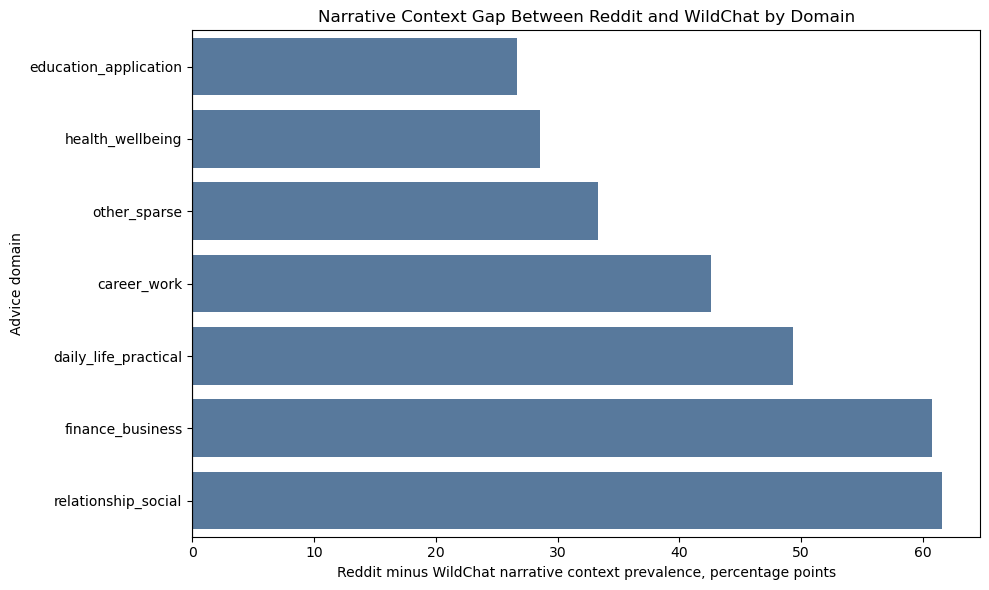

In [11]:
plot_gap = narrative_wide.sort_values("gap_reddit_minus_wildchat", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_gap,
    x="gap_reddit_minus_wildchat",
    y="domain_group",
    color="#4C78A8"
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Reddit minus WildChat narrative context prevalence, percentage points")
plt.ylabel("Advice domain")
plt.title("Narrative Context Gap Between Reddit and WildChat by Domain")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "figure_narrative_context_gap_by_domain.png", dpi=300, bbox_inches="tight")
plt.show()


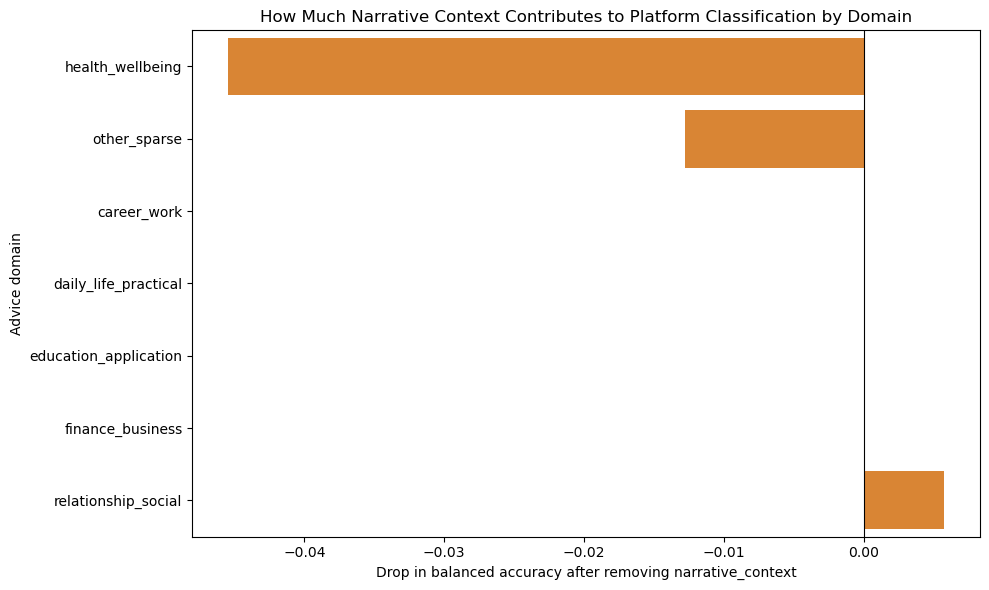

In [12]:
plot_drop = domain_ablation.sort_values("balanced_accuracy_drop", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_drop,
    x="balanced_accuracy_drop",
    y="domain_group",
    color="#F58518"
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Drop in balanced accuracy after removing narrative_context")
plt.ylabel("Advice domain")
plt.title("How Much Narrative Context Contributes to Platform Classification by Domain")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "figure_performance_drop_without_narrative_by_domain.png", dpi=300, bbox_inches="tight")
plt.show()

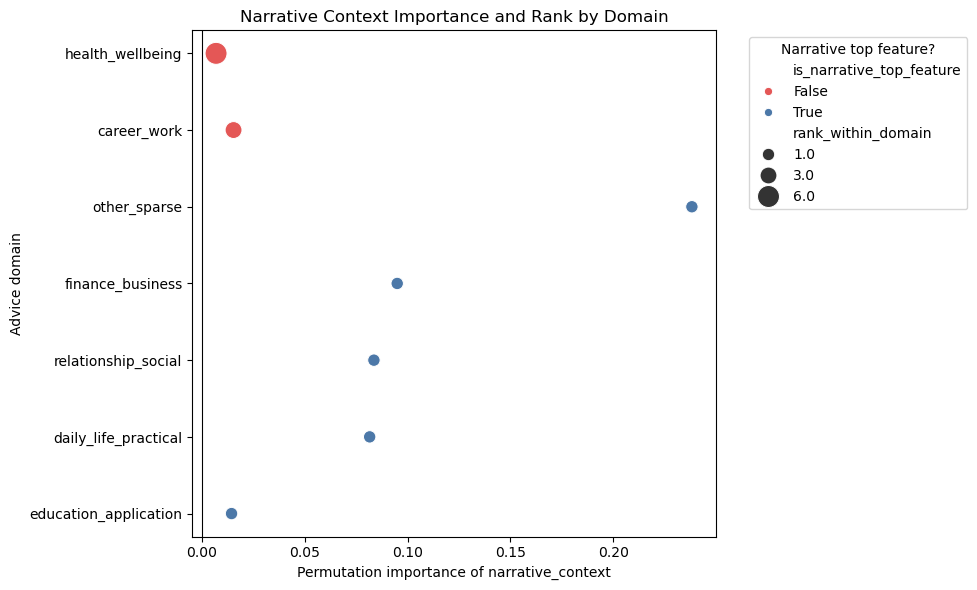

In [13]:
plot_rank = narrative_dominance.sort_values("rank_within_domain", ascending=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_rank,
    x="importance_mean",
    y="domain_group",
    size="rank_within_domain",
    hue="is_narrative_top_feature",
    sizes=(80, 250),
    palette={True: "#4C78A8", False: "#E45756"}
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Permutation importance of narrative_context")
plt.ylabel("Advice domain")
plt.title("Narrative Context Importance and Rank by Domain")
plt.legend(title="Narrative top feature?", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "figure_narrative_importance_rank_by_domain.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
## save results

# ==========================================
# Save all narrative-context ML results
# ==========================================

from pathlib import Path
import pandas as pd
import shutil

PROJECT_DIR = Path("/Users/harperli/Desktop/Warwick/Final paper")
OUTPUT_DIR = PROJECT_DIR / "data results" / "narrative_context_ml_analysis"
FINAL_DIR = PROJECT_DIR / "data results" / "narrative_context_final_results"

FINAL_DIR.mkdir(exist_ok=True)

# Files generated by the narrative-context analysis
files_to_copy = [
    "overall_narrative_ablation.csv",
    "narrative_context_prevalence_by_domain.csv",
    "domain_narrative_ablation.csv",
    "domain_specific_permutation_importance.csv",
    "narrative_context_dominance_by_domain.csv",
    "figure_narrative_context_gap_by_domain.png",
    "figure_performance_drop_without_narrative_by_domain.png",
    "figure_narrative_importance_rank_by_domain.png"
]

for file in files_to_copy:
    source = OUTPUT_DIR / file
    target = FINAL_DIR / file
    
    if source.exists():
        shutil.copy(source, target)
        print(f"Copied: {file}")
    else:
        print(f"Missing, not copied: {file}")

# Load key result tables
overall = pd.read_csv(OUTPUT_DIR / "overall_narrative_ablation.csv")
domain_ablation = pd.read_csv(OUTPUT_DIR / "domain_narrative_ablation.csv")
narrative_dominance = pd.read_csv(OUTPUT_DIR / "narrative_context_dominance_by_domain.csv")
narrative_prev = pd.read_csv(OUTPUT_DIR / "narrative_context_prevalence_by_domain.csv")

# Save an Excel workbook with all main tables
excel_path = FINAL_DIR / "narrative_context_all_results.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    overall.to_excel(writer, sheet_name="Overall ablation", index=False)
    narrative_prev.to_excel(writer, sheet_name="Narrative prevalence", index=False)
    domain_ablation.to_excel(writer, sheet_name="Domain ablation", index=False)
    narrative_dominance.to_excel(writer, sheet_name="Narrative dominance", index=False)

print(f"\nExcel workbook saved to:\n{excel_path}")

# Create a plain-language summary
summary_text = f"""
Narrative Context ML Follow-Up Results Summary

Purpose:
This analysis examines whether narrative_context, which was the strongest overall feature in the no-length ML model, is equally important across advice domains or whether its importance varies by domain.

Main analysis:
1. Overall narrative ablation:
   The model with narrative_context is compared against the same model with narrative_context removed.
   If performance drops after removing narrative_context, this suggests that narrative_context contributes to platform classification.

2. Domain-level prevalence:
   The analysis compares how often narrative_context appears in Reddit and WildChat within each advice domain.

3. Domain-level ablation:
   The analysis checks where model performance drops most after removing narrative_context.

4. Domain-specific permutation importance:
   The analysis checks whether narrative_context is the top-ranked feature within each domain.

Key files:
- overall_narrative_ablation.csv
- narrative_context_prevalence_by_domain.csv
- domain_narrative_ablation.csv
- domain_specific_permutation_importance.csv
- narrative_context_dominance_by_domain.csv
- narrative_context_all_results.xlsx

Figures:
- figure_narrative_context_gap_by_domain.png
- figure_performance_drop_without_narrative_by_domain.png
- figure_narrative_importance_rank_by_domain.png

Interpretation guide:
If narrative_context is top-ranked or removing it causes a large performance drop across most domains, it can be interpreted as a general platform-distinguishing feature.
If narrative_context is mainly important in relationship, family, or health domains, this suggests its importance is domain-specific and stronger in socially or emotionally loaded advice.
If narrative_context matters less in practical domains such as finance, education, or career, this suggests other request-style features may be more important there.
"""

summary_path = FINAL_DIR / "narrative_context_results_summary.txt"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(f"Summary saved to:\n{summary_path}")

print(f"\nAll final narrative-context results saved in:\n{FINAL_DIR}")

Copied: overall_narrative_ablation.csv
Copied: narrative_context_prevalence_by_domain.csv
Copied: domain_narrative_ablation.csv
Copied: domain_specific_permutation_importance.csv
Copied: narrative_context_dominance_by_domain.csv
Copied: figure_narrative_context_gap_by_domain.png
Copied: figure_performance_drop_without_narrative_by_domain.png
Copied: figure_narrative_importance_rank_by_domain.png

Excel workbook saved to:
/Users/harperli/Desktop/Warwick/Final paper/data results/narrative_context_final_results/narrative_context_all_results.xlsx
Summary saved to:
/Users/harperli/Desktop/Warwick/Final paper/data results/narrative_context_final_results/narrative_context_results_summary.txt

All final narrative-context results saved in:
/Users/harperli/Desktop/Warwick/Final paper/data results/narrative_context_final_results
